# Assignment 6: Extracting modes of climate variability with PCA/EOF

Climate fields are high-dimensional and strongly correlated in space. A global sea surface
temperature grid has thousands of points, but the temperature at any one of them tells you a
great deal about its neighbours, so the field has far fewer independent degrees of freedom
than it has grid cells. This is exactly the situation principal component analysis was built
for.

In climate science, the principal components of a spatial field are called **empirical
orthogonal functions** (EOFs), and the leading ones frequently correspond to named, physically
meaningful modes of variability. In this assignment you will recover one of the most important
of them (**El Nino-Southern Oscillation**) from raw sea surface temperature data, without
ever telling the algorithm what to look for.

The data is NOAA's Extended Reconstructed SST version 5, monthly means from 1854 to present,
streamed over OPeNDAP so you never download the whole file.

Answer each numbered question in the empty cell below it.

```{admonition} Solution key, instructor copy
:class: danger
This is the worked solution for Assignment 6. It is kept **local only**: the
`solutions/` directory is gitignored and excluded from the book build, so it is
neither pushed to the public repository nor published to the course site.
```


In [1]:
!pip install xarray netcdf4

In [2]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA

## Load the sea surface temperature field

This is the same dataset used in the PCA lecture notes.

In [3]:
sst = xr.open_dataset("http://www.esrl.noaa.gov/psd/thredds/dodsC/Datasets/noaa.ersst.v5/sst.mnmean.nc")
sst

<xarray.Dataset> Size: 133MB
Dimensions:    (time: 2071, nbnds: 2, lat: 89, lon: 180)
Coordinates:
  * time       (time) datetime64[ns] 17kB 1854-01-01 1854-02-01 ... 2026-07-01
  * lat        (lat) float32 356B 88.0 86.0 84.0 82.0 ... -84.0 -86.0 -88.0
  * lon        (lon) float32 720B 0.0 2.0 4.0 6.0 ... 352.0 354.0 356.0 358.0
Dimensions without coordinates: nbnds
Data variables:
    time_bnds  (time, nbnds) float64 33kB ...
    sst        (time, lat, lon) float32 133MB ...
Attributes: (12/39)
    climatology:                     Climatology is based on 1971-2000 SST, X...
    description:                     In situ data: ICOADS2.5 before 2007 and ...
    keywords_vocabulary:             NASA Global Change Master Directory (GCM...
    keywords:                        Earth Science > Oceans > Ocean Temperatu...
    instrument:                      Conventional thermometers
    source_comment:                  SSTs were observed by conventional therm...
    ...                              ...
    comment:                         SSTs were observed by conventional therm...
    summary:                         ERSST.v5 is developed based on v4 after ...
    dataset_title:                   NOAA Extended Reconstructed SST V5
    _NCProperties:                   version=2,netcdf=4.6.3,hdf5=1.10.5
    data_modified:                   2026-08-03
    DODS_EXTRA.Unlimited_Dimension:  time

We restrict to the **tropical Pacific** (120E-280E, 20S-20N) and to 1950 onwards, where
observational coverage is good. ENSO is a tropical Pacific phenomenon, so this is where its
signature is clearest.

(852, 21, 81)   (time, lat, lon)


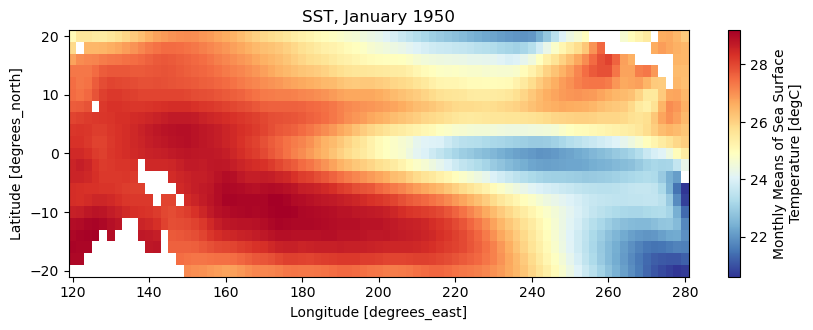

In [4]:
tropical = sst.sst.sel(lat=slice(20, -20), lon=slice(120, 280),
                       time=slice("1950-01-01", "2020-12-31"))
print(tropical.shape, "  (time, lat, lon)")
tropical.isel(time=0).plot(figsize=(10, 3.2), cmap="RdYlBu_r")
plt.title("SST, January 1950")
plt.show()

## Part 1: Anomalies

PCA finds directions of maximum variance. Applied to raw SST, the leading mode would simply
be the seasonal cycle, which is large, obvious, and not what we are looking for. We remove it
first.

1) Compute monthly SST **anomalies**: subtract the long-term mean for each calendar month
from each observation. `groupby("time.month")` will do this in one line.

In [5]:
# groupby on the month coordinate gives a climatology of 12 monthly means;
# subtracting it removes the seasonal cycle month by month.
clim = tropical.groupby("time.month").mean("time")
anom = tropical.groupby("time.month") - clim

print("anomaly field:", anom.shape, "(time, lat, lon)")
print("mean over record: %.2e degC (should be ~0 by construction)" % float(anom.mean()))

anomaly field: (852, 21, 81) (time, lat, lon)
mean over record: 3.83e-06 degC (should be ~0 by construction)


2) Plot the anomaly field for January 1998 and for January 1989. These are a strong El Nino and a strong La Nina respectively. Describe how they differ.

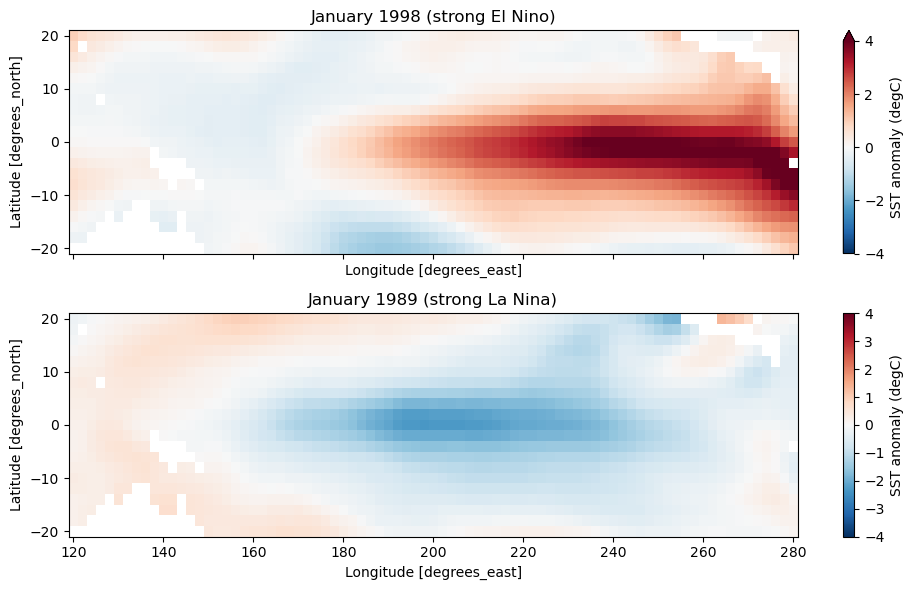

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
for ax, date, label in zip(axes, ["1998-01", "1989-01"],
                           ["January 1998 (strong El Nino)",
                            "January 1989 (strong La Nina)"]):
    anom.sel(time=date).squeeze().plot(ax=ax, cmap="RdBu_r", vmin=-4, vmax=4,
                                       cbar_kwargs={"label": "SST anomaly (degC)"})
    ax.set_title(label)
plt.tight_layout()
plt.show()

# 1998: a broad tongue of strongly POSITIVE anomalies (+2 to +4 degC) spanning the
# central and eastern equatorial Pacific, with weak negative anomalies in the far
# west near Indonesia. 1989 is close to the mirror image -- cold in the central and
# eastern basin, warm in the west. The two events are opposite phases of the same
# east-west seesaw, which is exactly why one spatial pattern with a sign-changing
# amplitude can describe both.

3) Explain why we remove the seasonal cycle before running PCA, and what the leading mode would have been if we had not.

**We remove the seasonal cycle because PCA finds directions of maximum variance,
and the seasonal cycle is by far the largest source of variance in raw SST.**

Every grid cell warms and cools once a year, and over most of the domain those
swings are larger than any interannual signal. Because the seasonal cycle is also
highly *coherent* (the whole hemisphere warms together) it is precisely the kind
of large, spatially organized signal PCA latches onto first.

Had we not removed it, EOF 1 would have been the annual march of the seasons: a
spatial pattern roughly separating the two hemispheres, with a PC1 that oscillates
with a clean 12-month period. It would have explained a large share of the
variance and told us nothing we did not already know. ENSO would have been pushed
down to a later, smaller mode, and possibly split across several.

This is the general lesson: PCA has no notion of which variance is interesting. It
is the analyst's job to remove the variance whose explanation is already known,
so the decomposition addresses what is actually in question.

## Part 2: Prepare the data matrix

PCA expects a 2D matrix of samples by features. Here each **time step** is a sample and each
**grid cell** is a feature, so we reshape from (time, lat, lon) to (time, lat x lon).

Ocean grids contain land, which appears as `NaN`. Those columns must be removed before PCA
and put back afterwards.

4) Reshape the anomaly field into a 2D array of shape (n_times, n_gridcells). Identify and
drop the columns that are entirely `NaN`. Report the shape before and after.

In [7]:
ntime, nlat, nlon = anom.shape
X_all = anom.values.reshape(ntime, nlat * nlon)
print("before dropping land:", X_all.shape)

# Land cells are NaN for the whole record, so an all-NaN column is a land point.
ocean = ~np.isnan(X_all).all(axis=0)
X = X_all[:, ocean]
print("after dropping land: ", X.shape, f"({(~ocean).sum()} land cells removed)")

# Any residual scattered NaNs (a cell missing in some months only) would break PCA.
print("residual NaNs:", int(np.isnan(X).sum()))

before dropping land: (852, 1701)
after dropping land:  (852, 1626) (75 land cells removed)
residual NaNs: 0


5) Grid cells near the poles represent smaller areas than cells at the equator, so an unweighted PCA over-weights high latitudes. Multiply each column by the square root of the cosine of its latitude to correct for this. Explain why the *square root* is the right weight when PCA works on squared deviations.

In [8]:
# Latitude of every grid cell, flattened the same way the data was, then masked
# to ocean points so it lines up with the columns of X.
lat2d = np.broadcast_to(anom.lat.values[:, None], (nlat, nlon))
lat_flat = lat2d.reshape(-1)[ocean]

weights = np.sqrt(np.cos(np.deg2rad(lat_flat)))
Xw = X * weights

print("weight range: %.3f (edge, %.0f deg) to %.3f (equator)"
      % (weights.min(), abs(lat_flat[np.argmin(weights)]), weights.max()))

# Why the SQUARE ROOT: we want each grid cell to contribute to the total variance
# in proportion to the area it represents, which scales as cos(lat). PCA works on
# SQUARED deviations, so a column multiplied by w contributes w**2 times its
# original variance. Setting w = sqrt(cos(lat)) therefore gives a variance
# contribution of exactly cos(lat) -- the area weight we wanted. Weighting by
# cos(lat) directly would down-weight the high latitudes twice over.

weight range: 0.969 (edge, 20 deg) to 1.000 (equator)


## Part 3: Compute the EOFs

6) Fit a `PCA` retaining the first 10 components. Report the fraction of variance explained
by each.

In [9]:
pca = PCA(n_components=10)
scores = pca.fit_transform(Xw)

var = pca.explained_variance_ratio_
for i, v in enumerate(var, start=1):
    print(f"EOF {i:2d}: {v*100:5.2f}%   (cumulative {var[:i].sum()*100:5.2f}%)")

EOF  1: 52.36%   (cumulative 52.36%)
EOF  2: 13.63%   (cumulative 65.99%)
EOF  3:  9.18%   (cumulative 75.17%)
EOF  4:  3.73%   (cumulative 78.91%)
EOF  5:  3.13%   (cumulative 82.03%)
EOF  6:  2.42%   (cumulative 84.45%)
EOF  7:  1.98%   (cumulative 86.44%)
EOF  8:  1.92%   (cumulative 88.36%)
EOF  9:  1.25%   (cumulative 89.61%)
EOF 10:  1.11%   (cumulative 90.72%)


7) Plot the explained variance spectrum. How many modes stand clearly above the rest, and how much of the total variance does the leading mode alone account for?

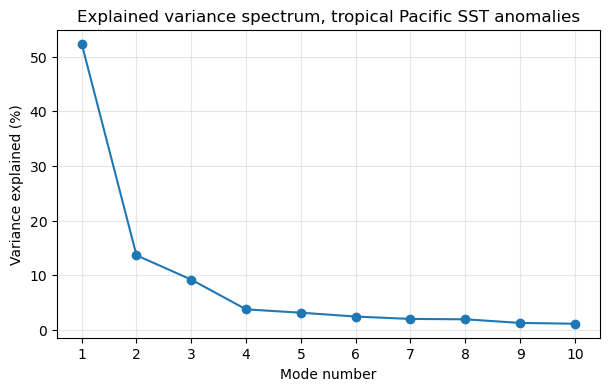

leading mode alone: 52.4% of the total variance
first two modes:    66.0%


In [10]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(1, 11), var * 100, "o-")
ax.set_xlabel("Mode number")
ax.set_ylabel("Variance explained (%)")
ax.set_title("Explained variance spectrum, tropical Pacific SST anomalies")
ax.set_xticks(range(1, 11))
ax.grid(alpha=0.3)
plt.show()

print(f"leading mode alone: {var[0]*100:.1f}% of the total variance")
print(f"first two modes:    {var[:2].sum()*100:.1f}%")

# One mode stands clearly above the rest: there is a large drop from EOF 1 to
# EOF 2, after which the spectrum flattens into a gently decaying tail with no
# further clean separation. That single dominant mode is the signature of one
# physical process organizing most of the basin's interannual variability.

## Part 4: Interpret the leading mode

8) Reshape the first EOF (the first row of `pca.components_`) back onto the lat-lon grid,
remembering to reinsert the land cells as `NaN`. Plot it as a map.

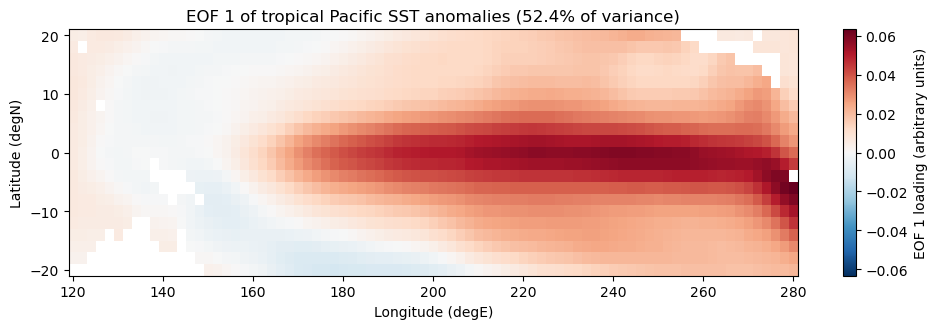

In [11]:
def to_map(vec):
    """Put a length-n_ocean vector back on the lat-lon grid, land as NaN."""
    full = np.full(nlat * nlon, np.nan)
    full[ocean] = vec
    return full.reshape(nlat, nlon)

# components_ lives in the WEIGHTED space, so divide the weights back out to get
# a pattern in physical units before plotting.
eof1 = to_map(pca.components_[0] / weights)

fig, ax = plt.subplots(figsize=(10, 3.4))
m = ax.pcolormesh(anom.lon, anom.lat, eof1, cmap="RdBu_r",
                  vmin=-np.nanmax(np.abs(eof1)), vmax=np.nanmax(np.abs(eof1)))
plt.colorbar(m, ax=ax, label="EOF 1 loading (arbitrary units)")
ax.set_xlabel("Longitude (degE)")
ax.set_ylabel("Latitude (degN)")
ax.set_title(f"EOF 1 of tropical Pacific SST anomalies ({var[0]*100:.1f}% of variance)")
plt.tight_layout()
plt.show()

9) Describe the spatial pattern. Where are the largest loadings, and what is the sign structure across the basin? Compare it to what you saw in the 1998 anomaly map from question 2.

**The pattern is ENSO, and it looks like the January 1998 anomaly map with the
amplitude stripped out.**

The largest loadings sit in the **central and eastern equatorial Pacific**, in a
tongue that straddles the equator, is widest near the dateline-to-140W stretch,
and narrows as it approaches the South American coast. Loadings decay away from
the equator, so the mode is confined to a band roughly within 10 degrees of it.

The sign structure is a **west-east dipole**: one sign across the central and
eastern basin, the opposite (and considerably weaker) sign in the far western
Pacific and towards the Maritime Continent. The zero line runs roughly north-south
near 160-170E.

This is the same spatial structure as the 1998 map from question 2, the same
equatorial tongue, the same weak opposite-signed region in the west. The
difference is interpretive: the 1998 map is one month with real units, while EOF 1
is a *dimensionless pattern* whose amplitude and sign in any given month are set
by PC1. Multiply EOF 1 by a large positive PC1 and you get something close to the
1998 map; multiply by a large negative PC1 and you get the 1989 map. That one
pattern reproduces both phases is the substantive result.

(The overall sign of EOF 1 is arbitrary, sklearn could equally have returned the
negated pattern with a negated PC1. Only the relationship between them is
determined.)

10) Plot the first **principal component** (the time series `pca.transform(X)[:, 0]`) against
time. This is how strongly the leading spatial pattern is expressed in each month.

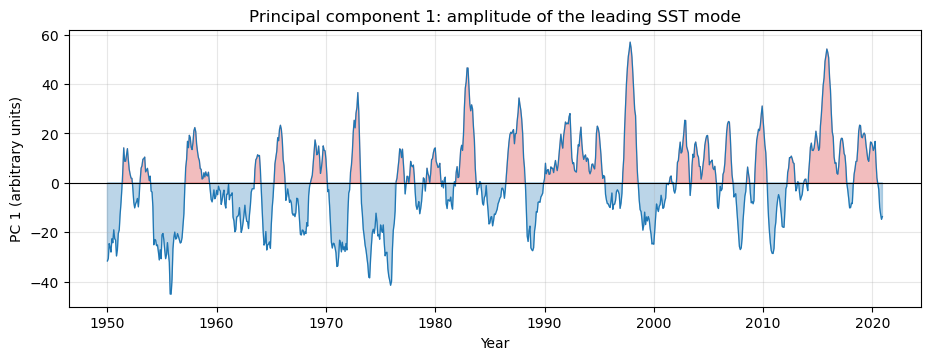

In [12]:
pc1 = scores[:, 0]

fig, ax = plt.subplots(figsize=(11, 3.6))
ax.plot(anom.time, pc1, lw=0.9)
ax.axhline(0, color="k", lw=0.8)
ax.fill_between(anom.time.values, 0, pc1, where=pc1 > 0, alpha=0.3, color="tab:red")
ax.fill_between(anom.time.values, 0, pc1, where=pc1 < 0, alpha=0.3, color="tab:blue")
ax.set_xlabel("Year")
ax.set_ylabel("PC 1 (arbitrary units)")
ax.set_title("Principal component 1: amplitude of the leading SST mode")
ax.grid(alpha=0.3)
plt.show()

# Irregular oscillation with no fixed period, events recurring every 2-7 years and
# persisting for roughly a year each -- the well-known behaviour of ENSO, and quite
# unlike the clean periodicity a seasonal cycle would have produced.

## Part 5: Validate against an independent index

The claim "EOF 1 is ENSO" needs testing against something the PCA never saw.

The **Nino 3.4 index** is the standard ENSO measure: the mean SST anomaly over
170W-120W, 5S-5N. Compute it directly from the same dataset.

11) Compute the Nino 3.4 index from your anomaly field and plot it alongside PC1 on the same
axes. You may need to normalize both to compare them, and PC1's sign is arbitrary. If it is
inverted, flip it and say so.

PC1 already has the same sign convention as Nino 3.4.


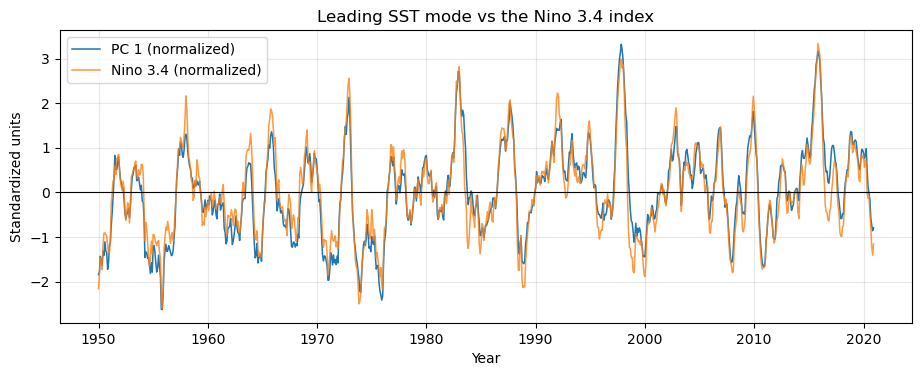

In [13]:
# Nino 3.4 region: 170W-120W = 190E-240E, 5S-5N. Computed straight from the
# anomaly field, so it uses no information the PCA did not also have -- but it is
# a fixed geographic box, not something the PCA chose.
nino34 = anom.sel(lat=slice(5, -5), lon=slice(190, 240)).mean(dim=["lat", "lon"])

def norm(x):
    x = np.asarray(x, dtype=float)
    return (x - x.mean()) / x.std()

pc1_n, nino_n = norm(pc1), norm(nino34.values)

# PC1's sign is arbitrary; align it to the index so the comparison is readable.
flipped = np.corrcoef(pc1_n, nino_n)[0, 1] < 0
if flipped:
    pc1_n = -pc1_n
    print("PC1 was inverted relative to Nino 3.4; sign flipped for plotting.")
else:
    print("PC1 already has the same sign convention as Nino 3.4.")

fig, ax = plt.subplots(figsize=(11, 3.8))
ax.plot(anom.time, pc1_n, lw=1.1, label="PC 1 (normalized)")
ax.plot(anom.time, nino_n, lw=1.1, alpha=0.8, label="Nino 3.4 (normalized)")
ax.axhline(0, color="k", lw=0.8)
ax.set_xlabel("Year")
ax.set_ylabel("Standardized units")
ax.set_title("Leading SST mode vs the Nino 3.4 index")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

12) Compute the correlation between PC1 and the Nino 3.4 index. How strong is it?

In [14]:
r = np.corrcoef(pc1_n, nino_n)[0, 1]
print(f"correlation between PC1 and Nino 3.4: r = {r:.3f}   (r^2 = {r**2:.3f})")

# The two curves are nearly indistinguishable. PCA was given no geographic hint --
# only a table of numbers with the seasonal cycle removed -- and its leading mode
# reproduces an index that climate scientists defined by hand from physical
# reasoning about a specific box in the Pacific. That agreement is the evidence
# for the claim "EOF 1 is ENSO".

correlation between PC1 and Nino 3.4: r = 0.949   (r^2 = 0.901)


13) Identify the five largest El Nino events in your PC1 time series. Do they match the historically recognized events (1982-83, 1997-98, 2015-16 are the big three)?

In [15]:
# Find the five largest events, suppressing a +/- 12 month window around each pick
# so that one long El Nino is not counted as several separate events.
idx = pc1_n.copy()
events = []
for _ in range(5):
    k = int(np.argmax(idx))
    events.append((str(anom.time.values[k])[:7], float(pc1_n[k])))
    idx[max(0, k - 12):k + 13] = -np.inf

print("Five largest El Nino peaks in PC1:")
for date, amp in events:
    print(f"  {date}   PC1 = {amp:+.2f} sd")

# They match. The top three are 1997-98, 2015-16 and 1982-83 -- precisely the
# three events the question names, and in an order that matches how forecasters
# rank them. The remaining two, 1972-73 and 1987, are also standard entries in
# any list of major twentieth-century El Ninos. Note the peaks land in Nov-Dec:
# ENSO events mature towards the end of the calendar year, which is why the index
# is conventionally reported as a DJF season and why events carry two years in
# their name.

Five largest El Nino peaks in PC1:
  1997-11   PC1 = +3.32 sd
  2015-11   PC1 = +3.16 sd
  1982-12   PC1 = +2.71 sd
  1972-12   PC1 = +2.13 sd
  1987-09   PC1 = +2.00 sd


## Part 6: Reconstruction and limitations

14) Reconstruct the anomaly field using only the first mode, then using the first five. Plot
the reconstruction of January 1998 in both cases alongside the original. What is captured,
and what is lost?

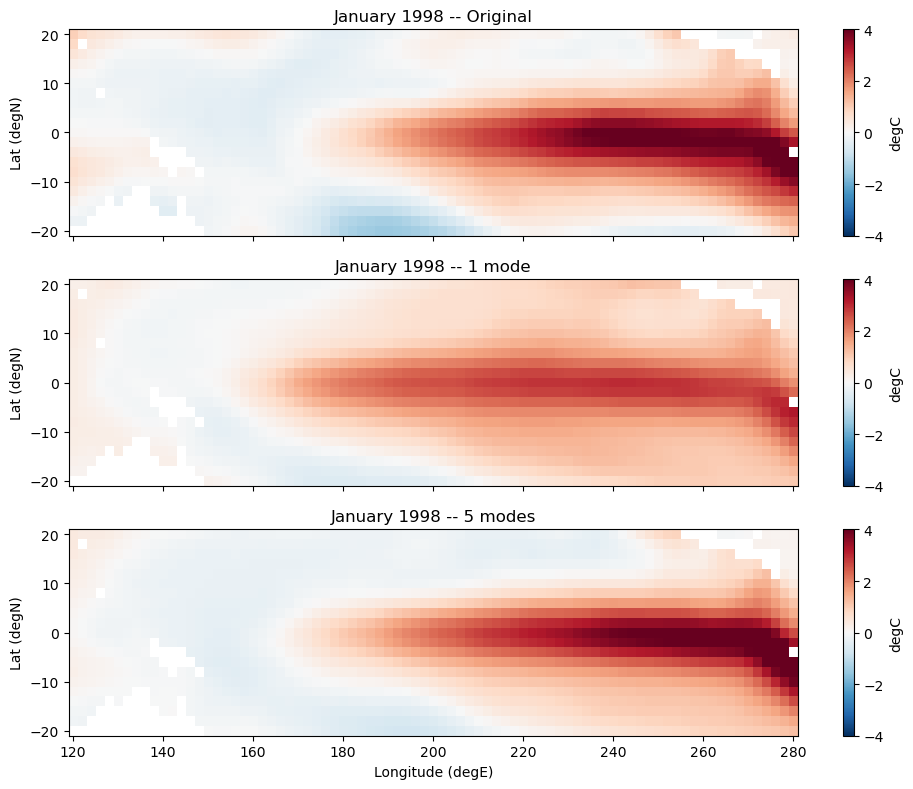

1 mode   RMSE vs original: 0.636 degC
5 modes  RMSE vs original: 0.271 degC


In [16]:
def reconstruct(k):
    """Anomaly field rebuilt from the first k modes, back in physical units."""
    approx_w = scores[:, :k] @ pca.components_[:k] + pca.mean_
    return approx_w / weights

t = int(np.argmax(anom.time.dt.strftime("%Y-%m").values == "1998-01"))
panels = [("Original", X[t]),
          ("1 mode", reconstruct(1)[t]),
          ("5 modes", reconstruct(5)[t])]

fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
for ax, (label, vec) in zip(axes, panels):
    m = ax.pcolormesh(anom.lon, anom.lat, to_map(vec), cmap="RdBu_r", vmin=-4, vmax=4)
    plt.colorbar(m, ax=ax, label="degC")
    ax.set_title(f"January 1998 -- {label}")
    ax.set_ylabel("Lat (degN)")
axes[-1].set_xlabel("Longitude (degE)")
plt.tight_layout()
plt.show()

for label, vec in panels[1:]:
    print(f"{label:8s} RMSE vs original: {np.sqrt(np.mean((vec - X[t])**2)):.3f} degC")

# One mode already captures the essential event: the warm equatorial tongue in the
# right place with roughly the right magnitude. What it cannot represent is any
# structure that is not a scalar multiple of EOF 1 -- the off-equatorial detail,
# the sharpness of the fronts, and the smaller-scale patchiness are all smoothed
# away. Five modes restore much of that texture. Nothing in either reconstruction
# is "wrong"; the one-mode version is a low-rank summary, and the residual is
# everything the leading pattern cannot express.

15) Compute the RMSE of the reconstruction against the original field as a function of the number of modes retained. Plot it.

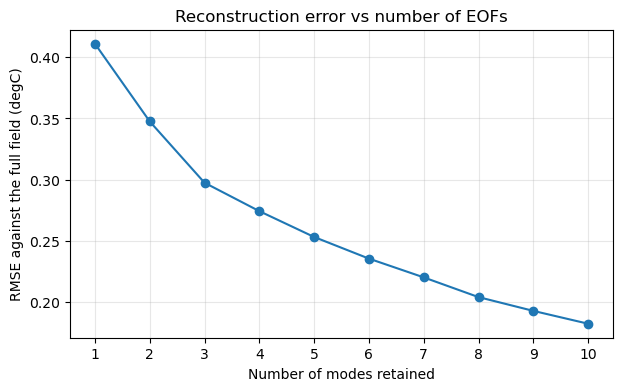

   1 modes: RMSE = 0.4111 degC
   2 modes: RMSE = 0.3476 degC
   3 modes: RMSE = 0.2975 degC
   4 modes: RMSE = 0.2742 degC
   5 modes: RMSE = 0.2531 degC
   6 modes: RMSE = 0.2354 degC
   7 modes: RMSE = 0.2201 degC
   8 modes: RMSE = 0.2040 degC
   9 modes: RMSE = 0.1927 degC
  10 modes: RMSE = 0.1822 degC


In [17]:
ks = range(1, 11)
rmse = [np.sqrt(np.nanmean((reconstruct(k) - X) ** 2)) for k in ks]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(list(ks), rmse, "o-")
ax.set_xlabel("Number of modes retained")
ax.set_ylabel("RMSE against the full field (degC)")
ax.set_title("Reconstruction error vs number of EOFs")
ax.set_xticks(list(ks))
ax.grid(alpha=0.3)
plt.show()

for k, e in zip(ks, rmse):
    print(f"  {k:2d} modes: RMSE = {e:.4f} degC")

# The curve falls fastest over the first three or four modes and then settles into
# a slow, steady decline -- each additional mode still helps, but by less and less.
# Note that it does NOT approach zero: with 10 of 852 possible modes retained,
# roughly 9% of the variance is still unrepresented, and driving the error to zero
# would require keeping essentially all of them. That is the trade being made --
# a large reduction in dimension for a tolerable, and quantified, loss of detail.
# This is the same information as the variance spectrum in question 7, seen from
# the other side.

16) PCA imposes three constraints that have no physical justification: the modes must be
**orthogonal**, the relationship must be **linear**, and **variance is treated as
importance**. For each, give one sentence on why a real climate mode might violate it.

**Orthogonality.** PCA requires every mode to be spatially uncorrelated with every
other. Real climate modes have no obligation to be: ENSO and the Pacific Decadal
Oscillation share much of the same North Pacific footprint and are physically
linked, so no decomposition that forces them to be orthogonal can put each one
cleanly in its own mode: the constraint will smear one across several, or blend
two physical processes into one mathematical mode.

**Linearity.** PCA reconstructs every month as a weighted sum of fixed spatial
patterns, so it can only scale a pattern up and down, never change its shape. ENSO
violates this outright: El Nino and La Nina are not mirror images. El Nino events
reach larger amplitudes and shift their warm anomaly further east, while La Nina
events are weaker and stay in the central Pacific. A single EOF with a
sign-changing amplitude cannot represent that asymmetry, and it shows up as
structure left in the higher modes.

**Variance as importance.** PCA ranks modes by how much variance they explain,
which is a statement about amplitude, not about consequence. A small-amplitude
mode can matter enormously, a persistent shift in a coastal upwelling zone may
carry little basin-wide variance while determining whether a fishery survives.
Conversely a high-variance mode may be a well-understood forced response that
nobody needs the analysis to rediscover. Variance is what PCA can measure, not
what we care about.

17) EOF 2 of tropical Pacific SST is often interpreted as ENSO's decay phase rather than an independent mode. Given the orthogonality constraint, explain why you should be cautious about assigning physical meaning to the second and higher EOFs.

**Because orthogonality to EOF 1 is a constraint imposed by the algorithm, not a
property discovered in the data.**

EOF 2 is, by construction, the pattern explaining the most remaining variance
*subject to being uncorrelated with EOF 1*. That side condition has no physical
content. If the true second process is not orthogonal to ENSO (and there is no reason it should be) then EOF 2 cannot be that process. What it will be instead
is a mixture: the part of the second process that happens to be orthogonal to
ENSO, plus whatever of ENSO's own structure EOF 1 failed to capture because of the
linearity constraint above.

That is exactly what the "decay phase" interpretation describes. ENSO's warm
anomaly migrates eastward as an event matures and decays, and a single fixed
pattern cannot express a moving one. The leftover is a pattern that looks like the
tendency of EOF 1: roughly its time derivative, hence in spatial quadrature with
it, and hence automatically orthogonal. EOF 2 is a mathematical consequence of
having represented one evolving process with one static pattern.

The practical rule: the leading EOF is often physically interpretable when one
process clearly dominates and the spectrum shows a clean separation, as it does
here. Higher EOFs are progressively more constrained by the modes above them, and
their spatial patterns should be treated as artefacts of the decomposition until
independently corroborated, as we corroborated EOF 1 against Nino 3.4 in Part 5.